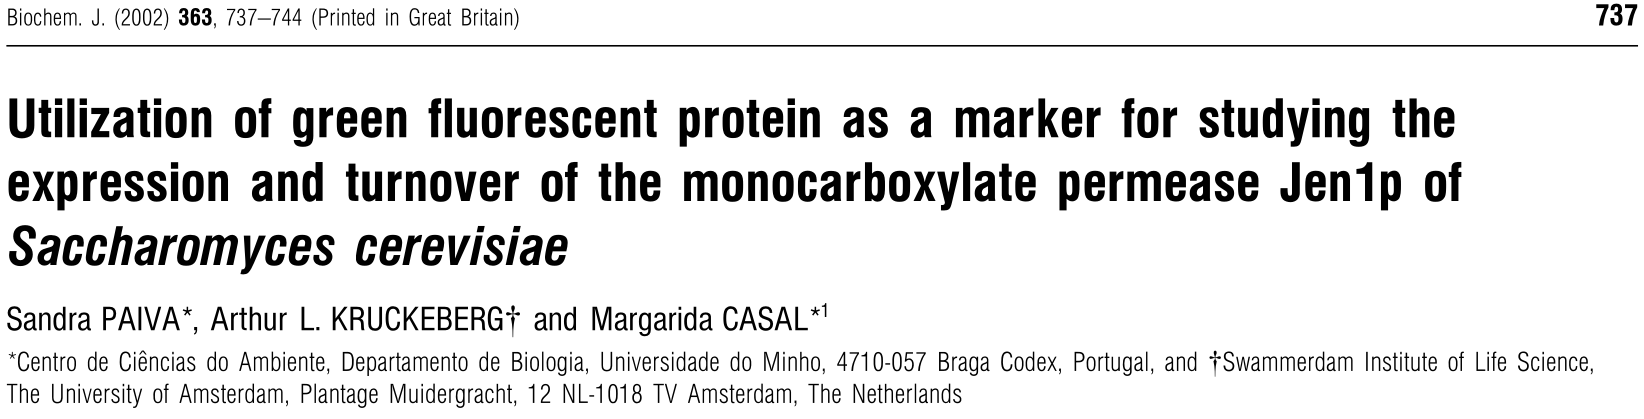

[link to paper](https://portlandpress.com/biochemj/article-abstract/363/3/737/40440/Utilization-of-green-fluorescent-protein-as-a?redirectedFrom=fulltext)

In [51]:
# if pydna_utils is not istalled, change the import below to:
# from pydna.genbank import genbank 
from pydna_utils.genbank import genbank

# Figure 1 (page 739) 
Strategies followed for the construction of the JEN1–GFP fusion (A) and for the verification of gene fusion by analytical PCR (B)

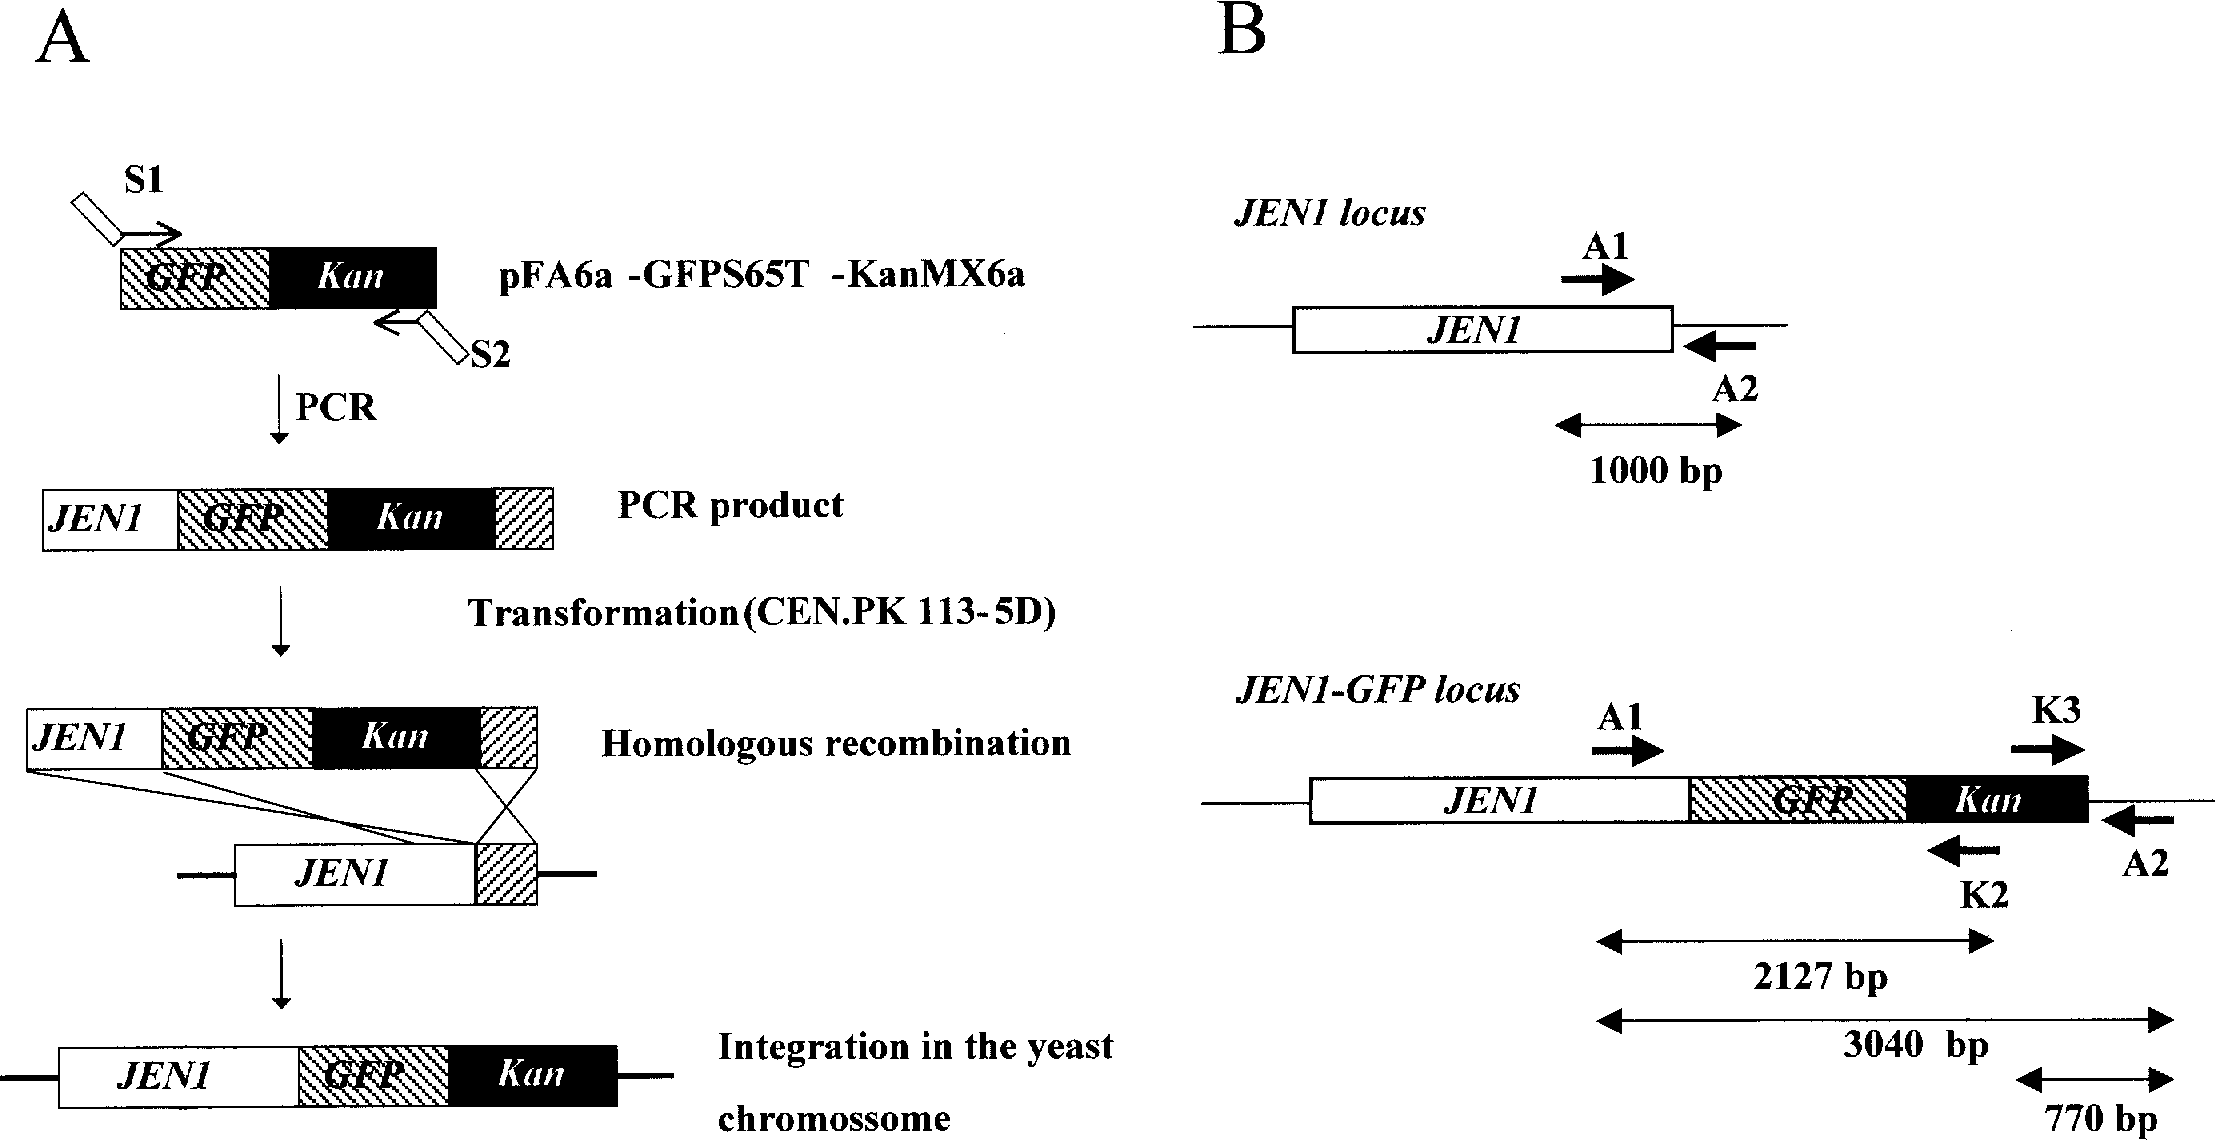

In [52]:
import math
import re
import regex
from pydna.parsers import parse_primers
from pydna.amplify import pcr
from pydna.assembly2 import homologous_recombination_integration

# Table 2 (page 738)

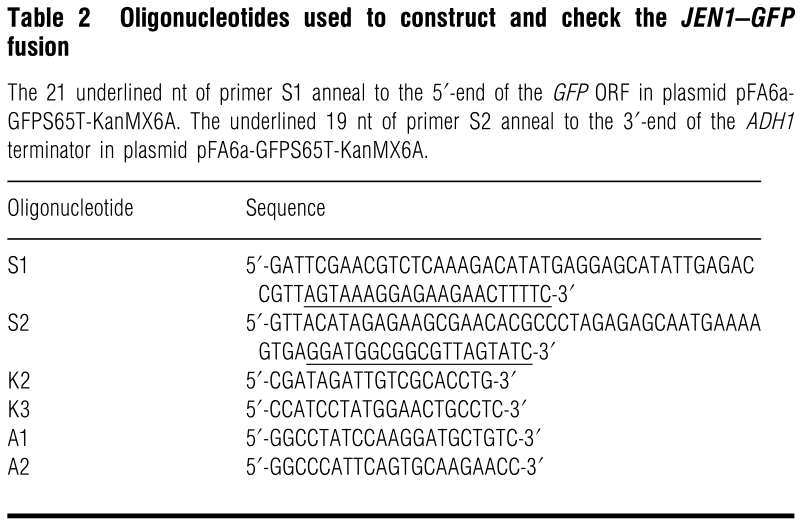

Primers below are from Table 2 above. [Free online OCR](https://www.newocr.com/) was used to extract the primer sequences, since the table seems to be an image in the PDF document.

The underlined part of the S1 primer above is different from the one recommended in Wach et al. 1997 (The source of the (pFA6a-GFPS65T-kanMX6 plasmid). 

    GAT-GCT-TAT-TGT-TTT-GCC-AAA-AAT-GAT-CTT-TTT-TTC-AAT-AAC-
                                                            -GGTCGACGGATCCCCGGG

    CT-GAT-GTA-CAG-AGA-TAT-ATT-ATA-CAT-TAC-AAT-TGT-ACA-AAC-
                                                           -ATCGATGAATTCGAGCTCG


This change removed a linker formed by the MCS between the two proteins:

    Upstream protein - GRRIPGLIN - SKGEELF...(GFP)...GMDELYK
                       --linker--
                       
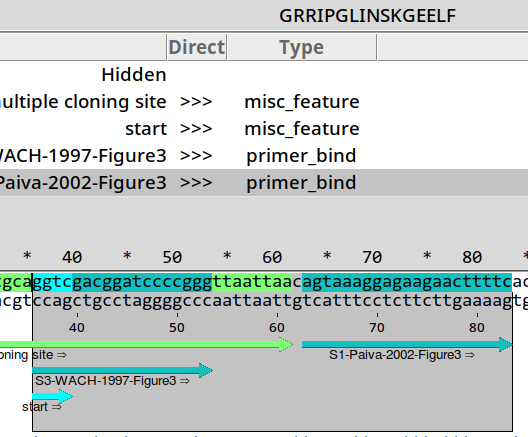

***

The reverse primer sits slightly upstream of the recommended primer. This avoids adding the PmeI restriction site into the PCR product.

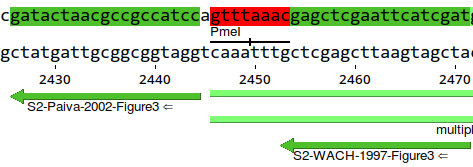


    ATT GAT TCG AAC GTC TCA AAG ACA TAT GAG GAG CAT ATT GAG ACC GTT TAA    <== JEN1 open reading frame
        GAT TCG AAC GTC TCA AAG ACA TAT GAG GAG CAT ATT GAG ACC GTT-
                                                                    |
                                                                     -AGTAAAGGAGAAGAACTTTTC    s1 primer



In [53]:
s1, s2, k2, k3, a1, a2 = parse_primers("""
>S1
GAT TCG AAC GTC TCA AAG ACA TAT GAG GAG CAT ATT GAG ACC GTT  AGTAAAGGAGAAGAACTTTTC
>S2
GTTACATAGAGAAGCGAACACGCCCTAGAGAGCAATGAAAAGTGA  GGATGGCGGCGTTAGTATC
>K2
CGATAGATTGTCGCACCTG
>K3
CCATCCTATGGAACTGCCTC
>Al
GGCCTATCCAAGGATGCTGTC
>A2
GGCCCATTCAGTGCAAGAACC
""")

In [54]:
# import os
# os.environ["pydna_email"] = "bjornjobb@gmail.com"

In [55]:
template = genbank("AJ002682.1")
assert len(template) == 4882
assert template.seguid() == 'ldseguid=zH5VDEw2UM9jjLVdEco_oZxzwss'

The [pFA6a-GFPS65T-kanMX6](https://www.ncbi.nlm.nih.gov/nuccore/AJ002682) plasmid has the Genbank accession number `AJ002682.1`. 

The Genbank entry has only this feature key/value related to GFP:

     source          63..776
                     /organism="Aequorea victoria"
                     /mol_type="other DNA"
                     /db_xref="taxon:6100"
                     /note="GFP gene (green fluorescent protein)"

The slice 62 .. 776 contain the protein below, a good candidate for GFP. We use 62 instead of 63 
since Python sequences are 0-indexed, while Genbank files start at 1. 

In [56]:
GFP_aa = template[62:776].seq.translate()
print(GFP_aa)

SKGEELFTGVVPILVELDGDVNGHKFSVSGEGEGDATYGKLTLKFICTTGKLPVPWPTLVTTFTYGVQCFSRYPDHMKRHDFFKSAMPEGYVQERTIFFKDDGNYKTRAEVKFEGDTLVNRIELKGIDFKEDGNILGHKLEYNYNSHNVYIMADKQKNGIKVNFKIRHNIEDGSVQLADHYQQNTPIGDGPVLLPDNHYLSTQSALSKDPNEKRDHMVLLEFVTAAGITHGMDELYK*


The protein sequence above was analyzed by protein [BLAST](https://www.uniprot.org/blast) at uniprot:

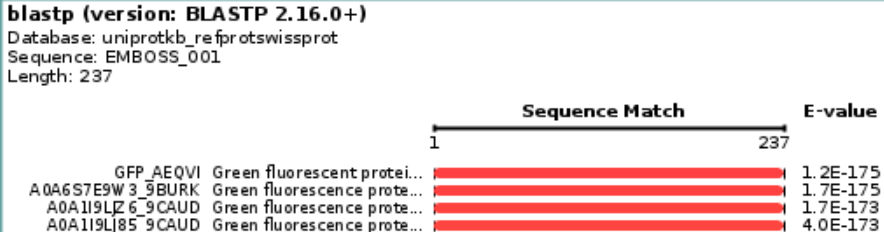

The protein sequence is identified as "GFP", which is what we want.

The cassette is amplified using primers s1 and s2 as described in the "A" panel above. 

In [57]:
cassette = pcr(s1, s2, template)

JEN1 sequence [SGD](https://www.yeastgenome.org/locus/JEN1)

In [58]:
locus = genbank("NC_001143.9", 22234-1000, 24084+1000)
assert locus.seguid() == "ldseguid=JztP6Y8QAjTIWOHIWS_dFz1JVHE"

In [59]:
locus

Dseqrecord(-3851)

The locus contain JEN1 and 1000 bp up & downstream.

In [60]:
JEN1_aa = locus[1000:-1000].seq.translate()

In [61]:
JEN1_aa

ProteinSeq('MSSSITDEKISGEQQQPAGRKLYYNTSTFAEPPLVDGEGNPINYEPEVYNPDHE...TV*')

In [62]:
len(JEN1_aa)

617

The protein sequence above was analyzed by protein [BLAST](https://www.uniprot.org/blast) at uniprot:

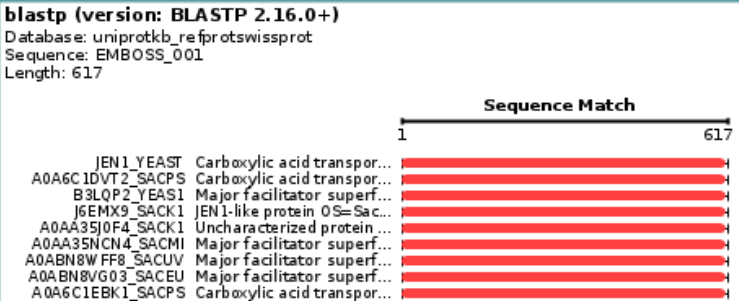

In [63]:
JEN1_GFP_fusion_protein = (JEN1_aa+GFP_aa).replace("*", "")

In [64]:
JEN1_GFP_fusion_protein

ProteinSeq('MSSSITDEKISGEQQQPAGRKLYYNTSTFAEPPLVDGEGNPINYEPEVYNPDHE...LYK')

In [65]:
JEN1_GFP_locus, *_ = homologous_recombination_integration(locus, [cassette])
assert JEN1_GFP_locus.seguid() == 'ldseguid=4fA-Rwp79zn53w-mlVBM89WodVg'

In [66]:
JEN1_GFP_locus.name = "JEN1_GFP_locus"
JEN1_GFP_locus.stamp()

ldseguid=4fA-Rwp79zn53w-mlVBM89WodVg

In [67]:
JEN1_GFP_locus.comment("""\
The S. cerevisiae JEN1 orf c-terminally tagged with GFP from pFA6a-GFPS65T-KanMX6.
""")

pydna ldseguid=4fA-Rwp79zn53w-mlVBM89WodVg 2026-04-08T12:38:28
The S. cerevisiae JEN1 orf c-terminally tagged with GFP from pFA6a-GFPS65T-KanMX6.

In [68]:
print(JEN1_GFP_locus.format())

LOCUS       JEN1_GFP_locus          6230 bp    DNA     linear   UNK 01-JAN-1980
DEFINITION  description.
ACCESSION   id
VERSION     id
DBLINK      BioProject: PRJNA128
            Assembly: GCF_000146045.2
KEYWORDS    .
SOURCE      
  ORGANISM  .
            .
COMMENT     pydna ldseguid=4fA-Rwp79zn53w-mlVBM89WodVg 2026-04-08T12:38:28
            The S. cerevisiae JEN1 orf c-terminally tagged with GFP from
            pFA6a-GFPS65T-KanMX6.
FEATURES             Location/Qualifiers
     source          2849..3562
                     /organism="Aequorea victoria"
                     /mol_type="other DNA"
                     /db_xref="taxon:6100"
                     /note="GFP gene (green fluorescent protein)"
     source          3571..3799
                     /organism="Saccharomyces cerevisiae"
                     /mol_type="other DNA"
                     /db_xref="taxon:4932"
                     /note="Terminator of ADH1 (alcohol dehydrogenase) gene"
     source          3810..4

Diagnostic PCR from the B panel above. The published results are given as comments:

In [69]:
pcr(a1, a2, locus) # 1000 bp

Amplicon(1060)

In [70]:
pcr(a1, k2, JEN1_GFP_locus) # 2127 bp

Amplicon(2116)

In [71]:
pcr(k3, a2, JEN1_GFP_locus) # 770 bp

Amplicon(760)

In [72]:
pcr(a1, a2, JEN1_GFP_locus) # 3040 bp

Amplicon(3439)

In [73]:
seq = JEN1_GFP_locus.seq

In [74]:
frame0 = seq + "n" * (-len(seq) % 3) 
frame1 = "n" + frame0[:-1]
frame2 = "n" + frame1[:-1]

In [75]:
assert len(frame0) == len(frame1) == len(frame2)

In [76]:
translated_frames = tuple(str(f.translate()) for f in (frame0, frame1, frame2))

In [77]:
singleframelength = len(translated_frames[0])

In [78]:
target = "msssi.+delyk".upper()

In [79]:
mobj = re.search(target, "".join(translated_frames))

In [80]:
mobj

<re.Match object; span=(4488, 5341), match='MSSSITDEKISGEQQQPAGRKLYYNTSTFAEPPLVDGEGNPINYEPEVY>

In [81]:
frame = math.ceil(mobj.start()/singleframelength) - 1
frame

2

In [82]:
start = mobj.start() * 3 - (3 * frame * singleframelength) - frame
start

1000

In [83]:
end = start + (mobj.end() - mobj.start())*3 + 3

In [84]:
end

3562

In [85]:
seq[start:end]

Dseq(-2562)
ATGT..ATAG
TACA..TATC

In [86]:
extracted_fusion_protein = seq[start:end].translate(stop_symbol="")

In [87]:
JEN1_GFP_fusion_protein

ProteinSeq('MSSSITDEKISGEQQQPAGRKLYYNTSTFAEPPLVDGEGNPINYEPEVYNPDHE...LYK')

In [88]:
extracted_fusion_protein

ProteinSeq('MSSSITDEKISGEQQQPAGRKLYYNTSTFAEPPLVDGEGNPINYEPEVYNPDHE...LYK')

In [89]:
assert extracted_fusion_protein == JEN1_GFP_fusion_protein

In [90]:
from pydna.align import align

In [91]:
aln, editlist = align(JEN1_GFP_fusion_protein, extracted_fusion_protein)

In [92]:
aln.counts()

<AlignmentCounts object (853 aligned letters; 853 identities; 0 mismatches; 0 gaps) at 0x7e3f9c369f70>

In [93]:
print(aln)

target            0 MSSSITDEKISGEQQQPAGRKLYYNTSTFAEPPLVDGEGNPINYEPEVYNPDHEKLYHNP
                  0 ||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||
query             0 MSSSITDEKISGEQQQPAGRKLYYNTSTFAEPPLVDGEGNPINYEPEVYNPDHEKLYHNP

target           60 SLPAQSIQDTRDDELLERVYSQDQGVEYEEDEEDKPNLSAASIKSYALTRFTSLLHIHEF
                 60 ||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||
query            60 SLPAQSIQDTRDDELLERVYSQDQGVEYEEDEEDKPNLSAASIKSYALTRFTSLLHIHEF

target          120 SWENVNPIPELRKMTWQNWNYFFMGYFAWLSAAWAFFCVSVSVAPLAELYDRPTKDITWG
                120 ||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||
query           120 SWENVNPIPELRKMTWQNWNYFFMGYFAWLSAAWAFFCVSVSVAPLAELYDRPTKDITWG

target          180 LGLVLFVRSAGAVIFGLWTDKSSRKWPYITCLFLFVIAQLCTPWCDTYEKFLGVRWITGI
                180 ||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||
query           180 LGLVLFVRSAGAVIFGLWTDKSSRKWPYITCLFLFVIAQLCTPWCDTYEKFLGVRWITGI

target          240 AMGG

In [94]:
assert JEN1_GFP_fusion_protein.seguid() == 'lsseguid=XPZS5iMC990Pyp1k9GjdCOmecbM'

In [95]:
UTR5 = seq[start-150:start+3]

In [96]:
list(re.finditer("ATG", str(UTR5)))

[<re.Match object; span=(12, 15), match='ATG'>,
 <re.Match object; span=(150, 153), match='ATG'>]

In [97]:
(len(UTR5) - UTR5.find("ATG"))%3 # 0 = in frame, 1 or 2 = out of frame

0

In [98]:
print(UTR5[12:])

ATGTATAAATACATTGCACATCATTGTTGAGAAATAGTTTTGGAAGTTGTCTAGTCCTTCTCCCTTAGATCTAAAAGGAAGAAGAGTAACAGTTTCAAAAGTTTTTCCTCAAAGAGATTAAATACTGCTACTGAAAATATG
